In [21]:
import pandas as pd
df_2013_2015 = pd.read_csv('data/shareData/분양가격/분양가_2013_2015.csv', encoding='cp949')
df_2013_2015.head()

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,...,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443
1,부산,8111,8111,9078,8965,9402,9501,9453,9457,9411,...,9208,9208,9204,9235,9279,9327,9345,9515,9559,9581
2,대구,8080,8080,8077,8101,8267,8274,8360,8360,8370,...,8439,8253,8327,8416,8441,8446,8568,8542,8542,8795
3,인천,10204,10204,10408,10408,10000,9844,10058,9974,9973,...,10020,10020,10017,9876,9876,9938,10551,10443,10443,10449
4,광주,6098,7326,7611,7346,7346,7523,7659,7612,7622,...,7752,7748,7752,7756,7861,7914,7877,7881,8089,8231


In [22]:
df_2015_2024 = pd.read_csv('data/shareData/분양가격/분양가_2015_2024.csv', encoding='cp949')
df_2015_2024.head()

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
0,서울,모든면적,2015,10,5841
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721
4,서울,전용면적 102제곱미터초과,2015,10,5879


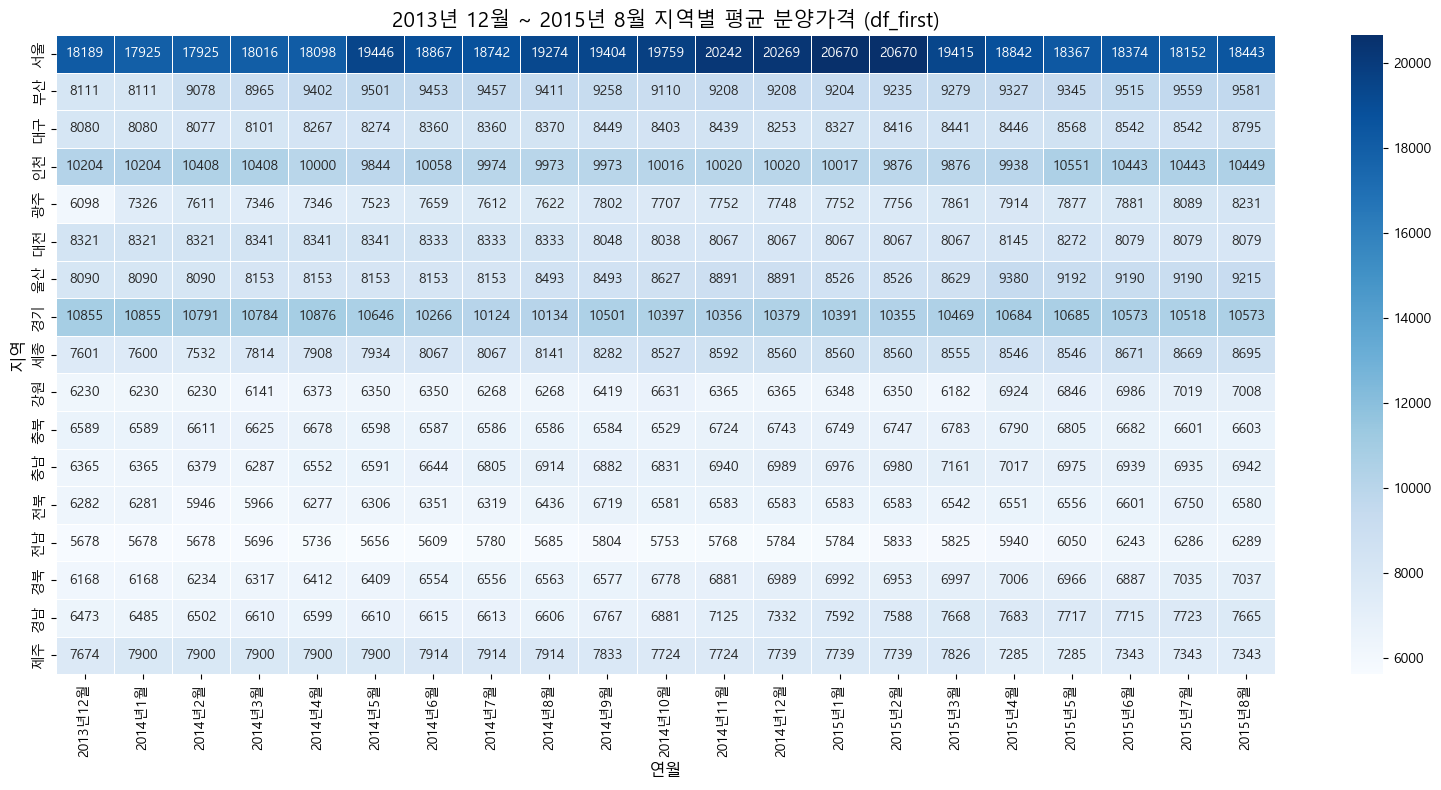

In [38]:
#1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

df_2013_2015 = pd.read_csv('data/shareData/분양가격/분양가_2013_2015.csv', encoding='cp949')

df_2013_2015.isnull().sum()

df_first = df_2013_2015.copy()
df_first_indexed = df_first.set_index('지역')

plt.figure(figsize=(16, 8))
sns.heatmap(
    df_first_indexed,
    cmap='Blues',
    annot=True,
    fmt='.0f',
    linewidths=0.5
)

plt.title('2013년 12월 ~ 2015년 8월 지역별 평균 분양가격 (df_first)', fontsize=15)
plt.xlabel('연월', fontsize=12)
plt.ylabel('지역', fontsize=12)

plt.tight_layout()
plt.show()

In [40]:
#2
import pandas as pd

df_2015_2024 = pd.read_csv('data/shareData/분양가격/분양가_2015_2024.csv', encoding='cp949')

df_last = df_2015_2024.copy()

target_col = [col for col in df_last.columns if '분양가격' in col][0]

def get_pyung_price(price):
    try:
        return float(str(price).strip().replace(',', '')) * 3.3
    except:
        return None

df_last['평당분양가격'] = df_last[target_col].apply(get_pyung_price)

df_last.head()

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),평당분양가격
0,서울,모든면적,2015,10,5841,19275.3
1,서울,전용면적 60제곱미터이하,2015,10,5652,18651.6
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882,19410.6
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721,18879.3
4,서울,전용면적 102제곱미터초과,2015,10,5879,19400.7


In [41]:
#3
import pandas as pd

df_pivot = df_last.pivot_table(
    index='지역명', 
    columns='연도', 
    values='평당분양가격', 
    aggfunc='mean'
)

df_pivot.columns.name = None
df_pivot.index.name = '지역명'

df_pivot

,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
지역명,,,,,,,,,,,,
강원,7188.060,7162.903846,7318.850000,8219.255000,8934.475000,10302.423214,10291.325000,11644.215000,13409.385000,15443.285000,15096.235000,17124.096000
경기,11060.940,11684.970000,12296.185000,14258.420000,15665.540000,15106.080000,14567.080000,16621.550000,20175.210000,22247.445000,23130.910000,22455.180000
경남,8459.220,8496.730000,8806.600000,9327.670000,10697.615789,10919.272222,11302.335000,12455.685000,13283.182759,13656.031915,14245.726415,15143.040000
경북,7464.160,7753.405000,8288.063793,8680.776923,9050.250000,9997.693750,11227.150000,12018.050000,13025.320000,14226.934615,14690.755814,14020.462500
광주,7916.700,9190.683333,9599.700000,9526.953333,12111.675000,13406.485714,13709.850000,15095.885106,17957.852830,18516.360000,17981.415517,21460.594737
대구,9018.900,10282.030000,12191.972222,12139.252632,14081.650000,15314.200000,15586.285000,16821.915000,17656.747059,22192.300000,23589.300000,31924.394118
대전,8190.600,8910.733333,9912.910526,10234.106667,12619.200000,11238.844737,11994.216667,14113.880000,17917.288889,19692.530000,20428.852632,18961.800000
부산,10377.400,10743.535000,11637.615000,12889.965000,13537.865000,13353.010000,14317.655000,18166.835593,20470.850847,22431.145000,26249.531579,28490.484000
서울,20315.680,21753.435000,21864.095000,23202.245000,28286.830000,29781.015000,29380.450000,29128.531034,33230.560000,44543.620000,47415.225000,50800.728000


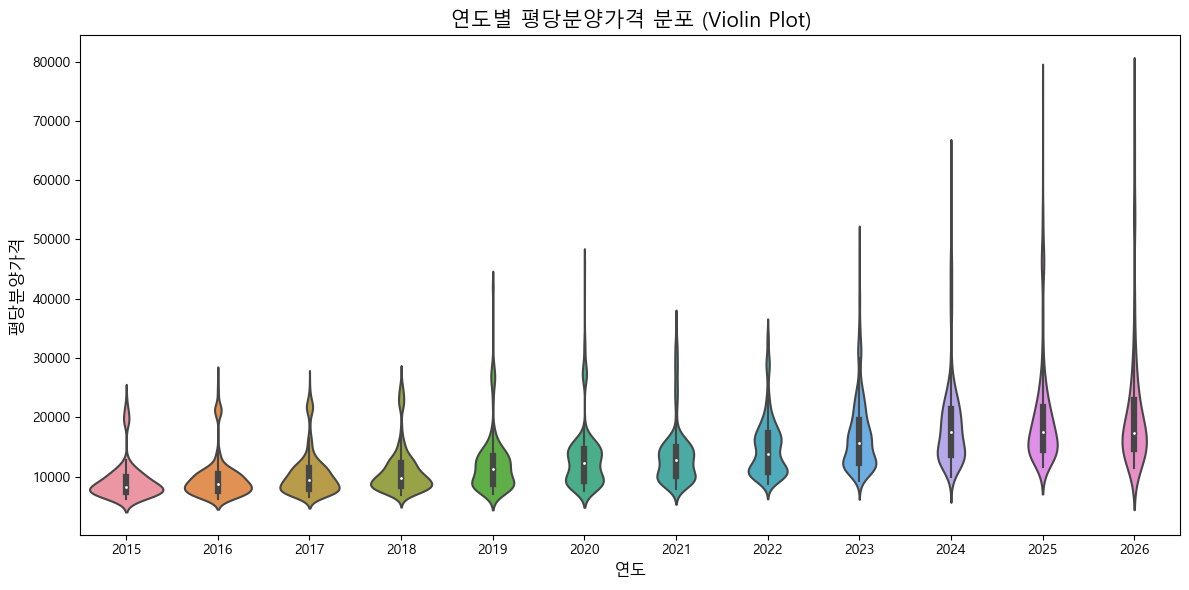

In [42]:
#4
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df_last,
    x='연도',
    y='평당분양가격'
)

plt.title('연도별 평당분양가격 분포 (Violin Plot)', fontsize=15)
plt.xlabel('연도', fontsize=12)
plt.ylabel('평당분양가격', fontsize=12)

plt.tight_layout()
plt.show()